In [1]:
import numpy as np
import matplotlib.pyplot as plt
import string
import os



plt.rcParams.update({
    "font.size": 11,            # base font size (tick labels)
    "axes.labelsize": 13,       # axis labels
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
})

import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_device', jax.devices('cpu')[0])

# Import your optimization and plotting utilities
from optimization_core import (
    build_jsa_grid,
    penalty_continuation_grad_desc,
    load_results,
    to_complex,
    tensor_knapsack_bound,
)



In [2]:
# ---------------------------------------------------------
# 1. Experiment parameters
# ---------------------------------------------------------

# Parameters for the multivariate normal distribution
n=20 # Number of points in the frequency grid nxnxn
d=6 # Dimensionality of the problem
mean = jnp.zeros(d) # Mean 
x_lim=2.5 # Limits in x and y ax0is for plotting

# # Sweep parameters
n_steps=36 # Number of steps in the sweep
rho_values=jnp.linspace(-0.19, 0.99 , n_steps) #rho_values is analogous to the correlation coefficients in the correlation matrix

In [3]:
sigma_list=[]
eta_list=[]
upper_bound_list=[]

for i,rho_value in enumerate(rho_values):
    # ---------------------------------------------------------
    # 1. Export data
    # ---------------------------------------------------------
    filename = f"eigen_eval_results_{d}D_20260617_r_{rho_value:.2f}.pkl"
    if os.path.exists('results_data/'+filename): 

        df,_,_=load_results(filename)
        f_pen = df["optim_lo"]
        fun_pen = df["eta"]

        # ---------------------------------------------------------
        # 2. Build JSA grid and initial mode
        # ---------------------------------------------------------
        print("Building JSA grid...")
        _, jsa_data = build_jsa_grid(n,mean, rho_value, x_lim)
        jsa_flat=jnp.reshape(jsa_data,(n,n**(d-1)))
        u, s, vt = jax.scipy.linalg.svd(jsa_flat, full_matrices=False)

        bound, tau_opt,sigma,mu,v_caps = tensor_knapsack_bound(jsa_data)

        # Compute bounds
        upper_bound = bound
        sigma_1 = s[0]

        # Print results
        print(rf"Actual $\eta$: {fun_pen:.4f}")
        print(f"Actual sigma_1: {sigma_1:.4f}")
        print(f"Upper bound: {jnp.abs(upper_bound):.4f}")
        sigma_list.append(sigma_1)
        eta_list.append(fun_pen)
        upper_bound_list.append(upper_bound)
    

Building JSA grid...


Actual $\eta$: 0.6538
Actual sigma_1: 0.8155
Upper bound: 0.6686
Building JSA grid...
Actual $\eta$: 0.8735
Actual sigma_1: 0.9497
Upper bound: 0.8768
Building JSA grid...
Actual $\eta$: 0.9443
Actual sigma_1: 0.9799
Upper bound: 0.9482
Building JSA grid...
Actual $\eta$: 0.9771
Actual sigma_1: 0.9921
Upper bound: 0.9781
Building JSA grid...
Actual $\eta$: 0.9927
Actual sigma_1: 0.9975
Upper bound: 0.9927
Building JSA grid...
Actual $\eta$: 0.9991
Actual sigma_1: 0.9997
Upper bound: 0.9991
Building JSA grid...
Actual $\eta$: 0.9997
Actual sigma_1: 0.9999
Upper bound: 0.9997
Building JSA grid...
Actual $\eta$: 0.9967
Actual sigma_1: 0.9989
Upper bound: 0.9967
Building JSA grid...
Actual $\eta$: 0.9910
Actual sigma_1: 0.9970
Upper bound: 0.9913
Building JSA grid...
Actual $\eta$: 0.9835
Actual sigma_1: 0.9944
Upper bound: 0.9841
Building JSA grid...
Actual $\eta$: 0.9745
Actual sigma_1: 0.9912
Upper bound: 0.9758
Building JSA grid...
Actual $\eta$: 0.9644
Actual sigma_1: 0.9875
Upper bou

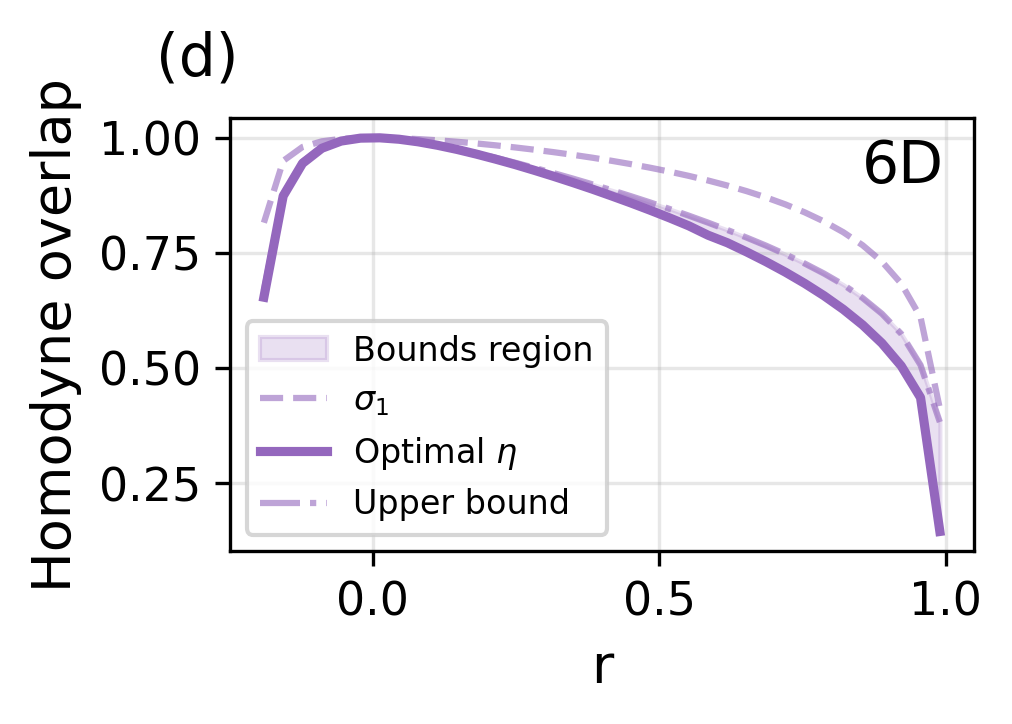

In [4]:
r_values = rho_values
sigma = jnp.array(sigma_list)
actual_value = jnp.array(eta_list)
upper_bound = jnp.array(upper_bound_list)


# plt.figure(figsize=(7,5))
fig, ax = plt.subplots(figsize=(3.4, 2.6))

base_color = "tab:purple"   # choose any: "tab:red", "tab:green", etc.

# --- Shaded region between lower and upper ---
ax.fill_between(
    r_values,
    actual_value,
    upper_bound,
    color=base_color,
    alpha=0.2,
    label="Bounds region"
)

# --- Sigma 1 ---
ax.plot(
    r_values,
    sigma,
    color=base_color,
    alpha=0.6,
    linestyle="--",
    label=r"$\sigma_1$"
)

# --- Actual value ---
ax.plot(
    r_values,
    actual_value,
    color=base_color,
    alpha=1.0,
    linewidth=2.2,
    label=r"Optimal $\eta$"
)

# --- Upper bound ---
ax.plot(
    r_values,
    upper_bound,
    color=base_color,
    alpha=0.6,
    linestyle="-.",
    label=r"Upper bound"
)

# Internal tag for dimensionality (e.g., "3D")
ax.text(
    0.85, 0.85, "6D",
    transform=ax.transAxes,
    fontsize=14
)

# Panel label (e.g., "(a)")
ax.text(
    -0.10, 1.1, "(d)",
    transform=ax.transAxes,
    fontsize=14
)

ax.set_xlabel("r")
ax.set_ylabel("Homodyne overlap")
ax.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"Bound_gaussian_{d}D_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()


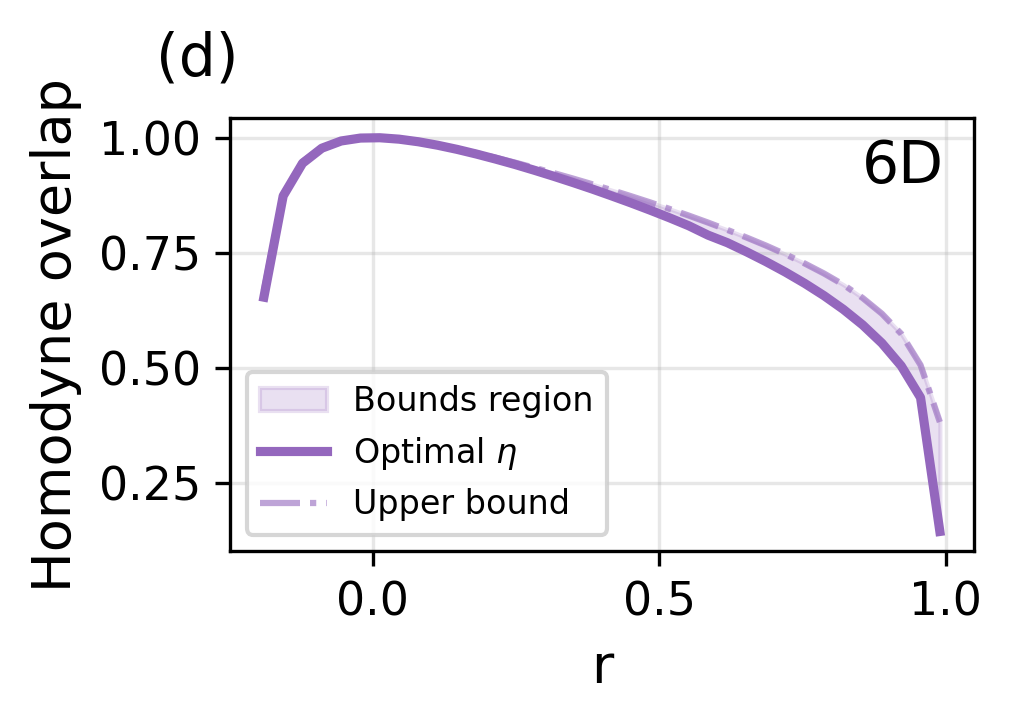

In [6]:
# plt.figure(figsize=(7,5))
fig, ax = plt.subplots(figsize=(3.4, 2.6))

base_color = "tab:purple"   # choose any: "tab:red", "tab:green", etc.

# --- Shaded region between lower and upper ---
ax.fill_between(
    r_values,
    actual_value,
    upper_bound,
    color=base_color,
    alpha=0.2,
    label="Bounds region"
)



# --- Actual value ---
ax.plot(
    r_values,
    actual_value,
    color=base_color,
    alpha=1.0,
    linewidth=2.2,
    label=r"Optimal $\eta$"
)

# --- Upper bound ---
ax.plot(
    r_values,
    upper_bound,
    color=base_color,
    alpha=0.6,
    linestyle="-.",
    label=r"Upper bound"
)

# Internal tag for dimensionality (e.g., "3D")
ax.text(
    0.85, 0.85, "6D",
    transform=ax.transAxes,
    fontsize=14
)

# Panel label (e.g., "(a)")
ax.text(
    -0.10, 1.1, "(d)",
    transform=ax.transAxes,
    fontsize=14
)

ax.set_xlabel("r")
ax.set_ylabel("Homodyne overlap")
ax.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"knapsack_bound_gaussian_{d}D_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()
